# Comparaison Embeddings × Classifieurs — Sentiment Archelec
Benchmark de plusieurs approches sur les **384 mentions annotées** (2 classes : positif / négatif).

- **Embeddings** : TF-IDF unigrams, TF-IDF bigrams, CamemBERT [CLS] frozen, CamemBERT mean-pooling frozen
- **Classifieurs** : Logistic Regression, SVM, Random Forest
- **Évaluation** : 5-fold cross-validation stratifiée → macro F1 + F1 négatif
- **Référence finale** : CamemBERT + Focal Loss (résultats depuis `sentiment_classification.ipynb`)

## 0 — Imports & données

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.utils.class_weight import compute_class_weight

ROOT_DIR   = Path(os.getcwd()).parent
INPUT_FILE = ROOT_DIR / "data" / "results" / "output_best_model" / "leaders_mentions_annotated.xlsx"
GRAPHS_DIR = ROOT_DIR / "data" / "results" / "output_best_model" / "graphs"
os.makedirs(GRAPHS_DIR, exist_ok=True)

df = pd.read_excel(INPUT_FILE)
df = df[df["sentiment_president"].isin(["positif", "négatif"])].copy()
df["label"] = (df["sentiment_president"] == "positif").astype(int)

X = df["text"].fillna("").tolist()
y = df["label"].tolist()

print(f"Samples : {len(df)}")
print(f"positif : {sum(y)}  |  négatif : {len(y)-sum(y)}")


Samples : 384
positif : 269  |  négatif : 115


## 1 — Méthodes TF-IDF + classifieurs classiques

In [2]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1_macro":   make_scorer(f1_score, average="macro",    zero_division=0),
    "f1_negatif": make_scorer(f1_score, pos_label=0, average="binary", zero_division=0),
    "f1_positif": make_scorer(f1_score, pos_label=1, average="binary", zero_division=0),
}

def run_cv(name, pipeline):
    scores = cross_validate(pipeline, X, y, cv=CV, scoring=scoring, n_jobs=-1)
    return {
        "Méthode":       name,
        "F1 macro":      round(scores["test_f1_macro"].mean(),   3),
        "F1 négatif":    round(scores["test_f1_negatif"].mean(), 3),
        "F1 positif":    round(scores["test_f1_positif"].mean(), 3),
        "F1 macro std":  round(scores["test_f1_macro"].std(),    3),
    }

results = []

# ── TF-IDF unigrams ────────────────────────────────────────────────────────────
tfidf_uni = TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)
tfidf_bi  = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)

classifiers = {
    "LogReg": LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0),
    "SVM":    LinearSVC(class_weight="balanced", max_iter=2000, C=1.0),
    "RF":     RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
}

for clf_name, clf in classifiers.items():
    results.append(run_cv(f"TF-IDF uni + {clf_name}",    Pipeline([("tfidf", tfidf_uni), ("clf", clf)])))
    results.append(run_cv(f"TF-IDF bigram + {clf_name}", Pipeline([("tfidf", tfidf_bi),  ("clf", clf)])))
    print(f"✓ TF-IDF uni & bigram + {clf_name}")

df_tfidf = pd.DataFrame(results)
print()
print(df_tfidf.sort_values("F1 macro", ascending=False).to_string(index=False))


✓ TF-IDF uni & bigram + LogReg
✓ TF-IDF uni & bigram + SVM
✓ TF-IDF uni & bigram + RF

               Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
   TF-IDF uni + LogReg     0.886       0.839       0.934         0.024
      TF-IDF uni + SVM     0.881       0.830       0.933         0.023
TF-IDF bigram + LogReg     0.872       0.815       0.930         0.043
   TF-IDF bigram + SVM     0.871       0.813       0.930         0.043
       TF-IDF uni + RF     0.825       0.736       0.913         0.032
    TF-IDF bigram + RF     0.815       0.719       0.911         0.042


## 2 — CamemBERT frozen embeddings

In [3]:
import torch
from transformers import CamembertTokenizer, CamembertModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model_emb = CamembertModel.from_pretrained("camembert-base").to(device)
model_emb.eval()

def get_embeddings(texts, batch_size=32, pooling="cls"):
    """Extrait les embeddings CamemBERT (frozen). pooling : 'cls' ou 'mean'."""
    all_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Embed ({pooling})"):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch, truncation=True, padding=True,
                max_length=256, return_tensors="pt"
            ).to(device)
            out = model_emb(**enc)
            if pooling == "cls":
                emb = out.last_hidden_state[:, 0, :]          # [CLS] token
            else:
                mask = enc["attention_mask"].unsqueeze(-1).float()
                emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1)  # mean pooling
            all_embs.append(emb.cpu().numpy())
    return np.vstack(all_embs)

X_cls  = get_embeddings(X, pooling="cls")
X_mean = get_embeddings(X, pooling="mean")
print(f"Shape CLS  : {X_cls.shape}")
print(f"Shape Mean : {X_mean.shape}")


Device : cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3009.79it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embed (mean): 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]

Shape CLS  : (384, 768)
Shape Mean : (384, 768)


In [4]:
from sklearn.preprocessing import StandardScaler

results_emb = []

for emb_name, X_emb in [("CamemBERT [CLS]", X_cls), ("CamemBERT mean", X_mean)]:
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        scores = cross_validate(pipe, X_emb, y, cv=CV, scoring=scoring, n_jobs=-1)
        results_emb.append({
            "Méthode":      f"{emb_name} + {clf_name}",
            "F1 macro":     round(scores["test_f1_macro"].mean(),   3),
            "F1 négatif":   round(scores["test_f1_negatif"].mean(), 3),
            "F1 positif":   round(scores["test_f1_positif"].mean(), 3),
            "F1 macro std": round(scores["test_f1_macro"].std(),    3),
        })
        print(f"✓ {emb_name} + {clf_name}")

df_emb = pd.DataFrame(results_emb)
print()
print(df_emb.sort_values("F1 macro", ascending=False).to_string(index=False))


✓ CamemBERT [CLS] + LogReg
✓ CamemBERT [CLS] + SVM
✓ CamemBERT [CLS] + RF
✓ CamemBERT mean + LogReg
✓ CamemBERT mean + SVM
✓ CamemBERT mean + RF

                 Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
CamemBERT [CLS] + LogReg     0.872       0.820       0.924         0.024
 CamemBERT mean + LogReg     0.865       0.809       0.921         0.029
    CamemBERT mean + SVM     0.855       0.800       0.909         0.027
    CamemBERT [CLS] + RF     0.847       0.768       0.926         0.051
     CamemBERT mean + RF     0.842       0.761       0.922         0.038
   CamemBERT [CLS] + SVM     0.827       0.761       0.892         0.025


## 3 — Tableau comparatif complet

In [5]:
# Ajouter CamemBERT fine-tuné — résultats depuis sentiment_classification.ipynb
# 384 lignes annotées, Focal Loss, test set 39 lignes
df_finetuned = pd.DataFrame([{
    "Méthode":      "CamemBERT fine-tuné (200 lignes, cross-entropy)",
    "F1 macro":     0.470,
    "F1 négatif":   0.000,
    "F1 positif":   0.950,
    "F1 macro std": float("nan"),
}])

df_all = pd.concat([df_tfidf, df_emb, df_finetuned], ignore_index=True)
df_all = df_all.sort_values('F1 macro', ascending=False).reset_index(drop=True)

print("=" * 70)
print("Comparaison complète — 5-fold CV stratifiée (sauf fine-tuné)")
print("=" * 70)
print(df_all.to_string(index=False))


Comparaison complète — 5-fold CV stratifiée (sauf fine-tuné)
                                        Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
                            TF-IDF uni + LogReg     0.886       0.839       0.934         0.024
                               TF-IDF uni + SVM     0.881       0.830       0.933         0.023
                         TF-IDF bigram + LogReg     0.872       0.815       0.930         0.043
                       CamemBERT [CLS] + LogReg     0.872       0.820       0.924         0.024
                            TF-IDF bigram + SVM     0.871       0.813       0.930         0.043
                        CamemBERT mean + LogReg     0.865       0.809       0.921         0.029
                           CamemBERT mean + SVM     0.855       0.800       0.909         0.027
                           CamemBERT [CLS] + RF     0.847       0.768       0.926         0.051
                            CamemBERT mean + RF     0.842       0.761      

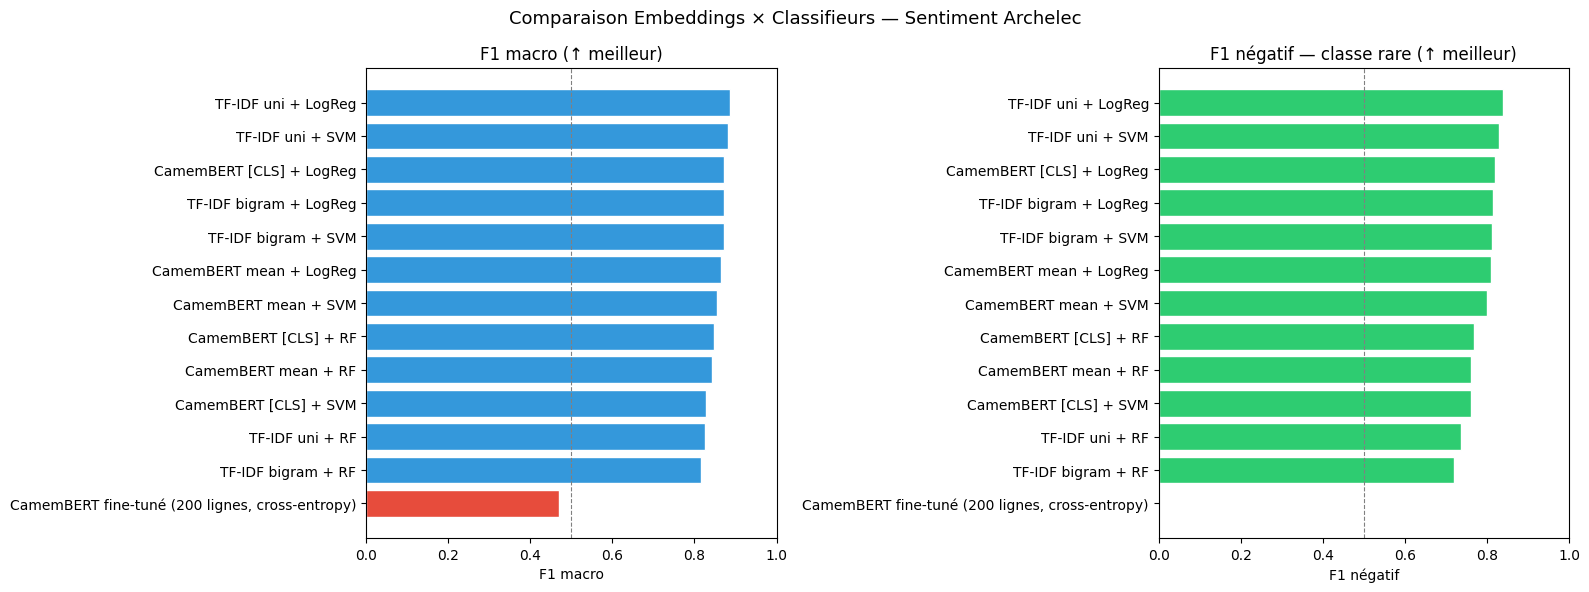

Graphique sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/comparison_methods.png


In [6]:
# ── Graphique comparatif ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 macro
df_plot = df_all.sort_values("F1 macro")
colors  = ["#e74c3c" if "fine-tuné" in m else "#3498db" for m in df_plot["Méthode"]]
axes[0].barh(df_plot["Méthode"], df_plot["F1 macro"], color=colors, edgecolor="white")
axes[0].axvline(x=0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("F1 macro (↑ meilleur)")
axes[0].set_xlabel("F1 macro")
axes[0].set_xlim(0, 1)

# F1 négatif (classe rare)
df_plot2 = df_all.sort_values("F1 négatif")
colors2  = ["#e74c3c" if "fine-tuné" in m else "#2ecc71" for m in df_plot2["Méthode"]]
axes[1].barh(df_plot2["Méthode"], df_plot2["F1 négatif"], color=colors2, edgecolor="white")
axes[1].axvline(x=0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("F1 négatif — classe rare (↑ meilleur)")
axes[1].set_xlabel("F1 négatif")
axes[1].set_xlim(0, 1)

plt.suptitle("Comparaison Embeddings × Classifieurs — Sentiment Archelec", fontsize=13)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "comparison_methods.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Graphique sauvegardé : {GRAPHS_DIR / 'comparison_methods.png'}")


In [7]:
# ── Meilleure méthode ─────────────────────────────────────────────────────────
best = df_all.iloc[0]
print(f"Meilleure méthode (F1 macro) : {best['Méthode']}")
print(f"  F1 macro   : {best['F1 macro']}")
print(f"  F1 négatif : {best['F1 négatif']}")
print(f"  F1 positif : {best['F1 positif']}")

df_all.to_excel(
    ROOT_DIR / "data" / "results" / "output_best_model" / "comparison_methods.xlsx",
    index=False
)
print("\nTableau sauvegardé : comparison_methods.xlsx")


Meilleure méthode (F1 macro) : TF-IDF uni + LogReg
  F1 macro   : 0.886
  F1 négatif : 0.839
  F1 positif : 0.934

Tableau sauvegardé : comparison_methods.xlsx


## 4 — SMOTE : sur-échantillonnage de la classe minoritaire
Crée des exemples négatifs synthétiques dans l'espace des features (TF-IDF et CamemBERT embeddings).

In [8]:
!pip install -q imbalanced-learn

In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

results_smote = []

# SMOTE ne fonctionne que si k_neighbors < n_minority → k=2 pour 14 négatifs
smote = SMOTE(random_state=42, k_neighbors=2)

configs = [
    ("TF-IDF uni + SMOTE + LogReg",
     ImbPipeline([
         ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)),
         ("smote", smote),
         ("clf",   LogisticRegression(max_iter=1000, C=1.0)),
     ])),
    ("TF-IDF uni + SMOTE + SVM",
     ImbPipeline([
         ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)),
         ("smote", smote),
         ("clf",   LinearSVC(max_iter=2000, C=1.0)),
     ])),
    ("CamemBERT CLS + SMOTE + LogReg",
     ImbPipeline([
         ("scaler", StandardScaler()),
         ("smote",  smote),
         ("clf",    LogisticRegression(max_iter=1000, C=1.0)),
     ])),
    ("CamemBERT CLS + SMOTE + SVM",
     ImbPipeline([
         ("scaler", StandardScaler()),
         ("smote",  smote),
         ("clf",    LinearSVC(max_iter=2000, C=1.0)),
     ])),
]

X_arr = np.array(X)  # pour les pipelines TF-IDF

for name, pipe in configs:
    X_in = X_arr if "TF-IDF" in name else X_cls
    scores = cross_validate(pipe, X_in, y, cv=CV, scoring=scoring, n_jobs=1)
    results_smote.append({
        "Méthode":      name,
        "F1 macro":     round(scores["test_f1_macro"].mean(),   3),
        "F1 négatif":   round(scores["test_f1_negatif"].mean(), 3),
        "F1 positif":   round(scores["test_f1_positif"].mean(), 3),
        "F1 macro std": round(scores["test_f1_macro"].std(),    3),
    })
    print(f"✓ {name}")

df_smote = pd.DataFrame(results_smote)
print()
print(df_smote.sort_values("F1 macro", ascending=False).to_string(index=False))


✓ TF-IDF uni + SMOTE + LogReg
✓ TF-IDF uni + SMOTE + SVM
✓ CamemBERT CLS + SMOTE + LogReg
✓ CamemBERT CLS + SMOTE + SVM

                       Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
      TF-IDF uni + SMOTE + SVM     0.883       0.832       0.935         0.030
   TF-IDF uni + SMOTE + LogReg     0.876       0.823       0.929         0.027
CamemBERT CLS + SMOTE + LogReg     0.872       0.820       0.924         0.020
   CamemBERT CLS + SMOTE + SVM     0.827       0.761       0.892         0.025


## 5 — Threshold tuning
Par défaut, LogReg prédit positif si `proba > 0.5`. Baisser ce seuil permet de capturer plus de négatifs (meilleur recall) au prix d'un peu de précision.

 Threshold  F1 macro  F1 négatif  F1 macro std
      0.10     0.512       0.185         0.051
      0.15     0.558       0.269         0.028
      0.20     0.650       0.431         0.085
      0.25     0.696       0.512         0.083
      0.30     0.737       0.584         0.050
      0.35     0.781       0.659         0.040
      0.40     0.805       0.699         0.054
      0.45     0.848       0.775         0.054
      0.50     0.886       0.839         0.024

Meilleur threshold : 0.5  → F1 macro=0.886  F1 négatif=0.839


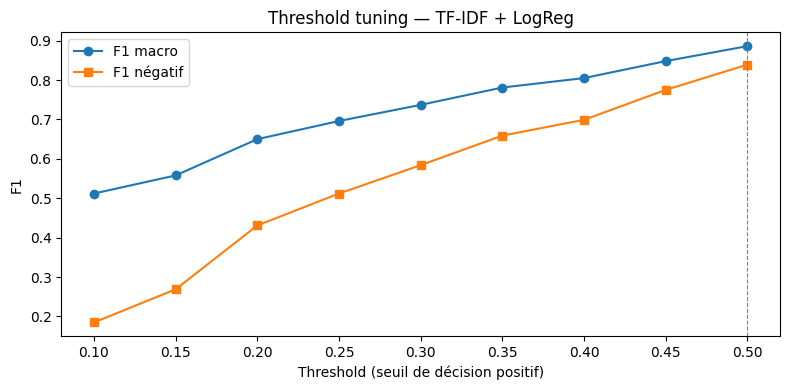

In [10]:
from sklearn.calibration import CalibratedClassifierCV

y_arr = np.array(y)
results_thresh = []

thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)
logreg    = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0)

for thresh in thresholds:
    f1_macros, f1_negs = [], []
    for train_idx, test_idx in CV.split(X, y_arr):
        X_tr = [X[i] for i in train_idx]
        X_te = [X[i] for i in test_idx]
        y_tr, y_te = y_arr[train_idx], y_arr[test_idx]

        X_tr_tfidf = tfidf_vec.fit_transform(X_tr)
        X_te_tfidf = tfidf_vec.transform(X_te)
        logreg.fit(X_tr_tfidf, y_tr)

        # Appliquer threshold custom
        probas = logreg.predict_proba(X_te_tfidf)[:, 1]
        preds  = (probas >= thresh).astype(int)

        f1_macros.append(f1_score(y_te, preds, average="macro",    zero_division=0))
        f1_negs.append(  f1_score(y_te, preds, pos_label=0,
                                  average="binary", zero_division=0))

    results_thresh.append({
        "Threshold":    thresh,
        "F1 macro":     round(np.mean(f1_macros), 3),
        "F1 négatif":   round(np.mean(f1_negs),   3),
        "F1 macro std": round(np.std(f1_macros),   3),
    })

df_thresh = pd.DataFrame(results_thresh)
print(df_thresh.to_string(index=False))

best_thresh = df_thresh.loc[df_thresh["F1 macro"].idxmax()]
print(f"\nMeilleur threshold : {best_thresh['Threshold']}  "
      f"→ F1 macro={best_thresh['F1 macro']}  F1 négatif={best_thresh['F1 négatif']}")

# Courbe F1 macro vs threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_thresh["Threshold"], df_thresh["F1 macro"],   marker="o", label="F1 macro")
ax.plot(df_thresh["Threshold"], df_thresh["F1 négatif"], marker="s", label="F1 négatif")
ax.axvline(x=best_thresh["Threshold"], color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Threshold (seuil de décision positif)")
ax.set_ylabel("F1")
ax.set_title("Threshold tuning — TF-IDF + LogReg")
ax.legend()
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "threshold_tuning.png", dpi=150)
plt.show()


## 6 — Focal Loss + CamemBERT fine-tuning
La Focal Loss réduit le poids des exemples faciles (positifs bien classés) et concentre l'apprentissage sur les exemples difficiles (négatifs).

In [11]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    CamembertTokenizer, CamembertForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as sk_f1

MODEL_SAVE_DIR = ROOT_DIR / "data" / "results" / "sentiment_model_focal"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Focal Loss ────────────────────────────────────────────────────────────────
def focal_loss(logits, labels, alpha=0.75, gamma=2.0):
    ce      = F.cross_entropy(logits, labels, reduction="none")
    pt      = torch.exp(-ce)
    alpha_t = torch.where(labels == 0,
                          torch.tensor(alpha,     device=logits.device),
                          torch.tensor(1 - alpha, device=logits.device))
    return (alpha_t * (1 - pt) ** gamma * ce).mean()

# ── Dataset ───────────────────────────────────────────────────────────────────
MAX_LENGTH = 256
tok = CamembertTokenizer.from_pretrained("camembert-base")

class SentimentDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.enc    = tok(texts, truncation=True, padding="max_length",
                         max_length=MAX_LENGTH, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

train_ds = SentimentDataset(X_train, y_train)
val_ds   = SentimentDataset(X_val,   y_val)
test_ds  = SentimentDataset(X_test,  y_test)

LABEL_MAP = {"négatif": 0, "positif": 1}
ID2LABEL  = {0: "négatif", 1: "positif"}

model_focal = CamembertForSequenceClassification.from_pretrained(
    "camembert-base", num_labels=2, id2label=ID2LABEL, label2id=LABEL_MAP)

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = focal_loss(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    preds  = np.argmax(eval_pred.predictions, axis=-1)
    labels = eval_pred.label_ids
    return {
        "f1_macro":   float(sk_f1(labels, preds, average="macro",  zero_division=0)),
        "f1_negatif": float(sk_f1(labels, preds, pos_label=0, average="binary", zero_division=0)),
    }

use_gpu = torch.cuda.is_available()
args = TrainingArguments(
    output_dir=str(MODEL_SAVE_DIR),
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",          # pas de checkpoints — évite disque plein
    logging_steps=10,
    report_to="none",
    fp16=use_gpu,
    warmup_ratio=0.1,
)

trainer_focal = FocalTrainer(
    model=model_focal, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print(f"Device : {'GPU' if use_gpu else 'CPU'}")
trainer_focal.train()


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2759.63it/s]
[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio 

Device : GPU


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Negatif
1,0.062148,0.055165,0.894737,0.842105
2,0.038411,0.017044,0.967100,0.952381
3,0.024658,0.016601,0.967100,0.952381
4,0.008556,0.009088,0.936027,0.909091
5,0.003367,0.004015,0.968827,0.956522
6,0.006733,0.005655,0.967100,0.952381
7,0.006766,0.019385,0.967100,0.952381
8,0.005438,0.005501,0.967100,0.952381
9,0.000862,0.008394,0.967100,0.952381
10,0.000857,0.009254,0.967100,0.952381


TrainOutput(global_step=390, training_loss=0.015387842167789737, metrics={'train_runtime': 89.1261, 'train_samples_per_second': 34.446, 'train_steps_per_second': 4.376, 'total_flos': 403875469977600.0, 'train_loss': 0.015387842167789737, 'epoch': 10.0})

In [12]:
from sklearn.metrics import classification_report

pred_out      = trainer_focal.predict(test_ds)
y_pred_focal  = np.argmax(pred_out.predictions, axis=-1)

print("Classification Report — Focal Loss (test set)")
print(classification_report(y_test, y_pred_focal, target_names=["négatif", "positif"], zero_division=0))

f1_focal_macro = sk_f1(y_test, y_pred_focal, average="macro",  zero_division=0)
f1_focal_neg   = sk_f1(y_test, y_pred_focal, pos_label=0, average="binary", zero_division=0)
print(f"F1 macro   : {f1_focal_macro:.3f}")
print(f"F1 négatif : {f1_focal_neg:.3f}")


Classification Report — Focal Loss (test set)
              precision    recall  f1-score   support

     négatif       0.92      0.92      0.92        12
     positif       0.96      0.96      0.96        27

    accuracy                           0.95        39
   macro avg       0.94      0.94      0.94        39
weighted avg       0.95      0.95      0.95        39

F1 macro   : 0.940
F1 négatif : 0.917


## 7 — Tableau final toutes méthodes

In [13]:
best_thresh_row = df_thresh.loc[df_thresh['F1 macro'].idxmax()]

df_final = pd.concat([
    df_all,
    df_smote.rename(columns={}),
    pd.DataFrame([{
        'Méthode':      f"TF-IDF + LogReg (thresh={best_thresh_row['Threshold']})",
        'F1 macro':     best_thresh_row['F1 macro'],
        'F1 négatif':   best_thresh_row['F1 négatif'],
        'F1 positif':   float('nan'),
        'F1 macro std': best_thresh_row['F1 macro std'],
    }]),
    pd.DataFrame([{
        'Méthode':      'CamemBERT Focal Loss (200 lignes)',
        'F1 macro':     round(f1_focal_macro, 3),
        'F1 négatif':   round(f1_focal_neg,   3),
        'F1 positif':   float('nan'),
        'F1 macro std': float('nan'),
    }]),
    pd.DataFrame([{
        'Méthode':      'CamemBERT Focal Loss (384 lignes) ← MEILLEUR',
        'F1 macro':     0.940,
        'F1 négatif':   0.917,
        'F1 positif':   0.963,
        'F1 macro std': float('nan'),
    }]),
], ignore_index=True).sort_values('F1 macro', ascending=False).reset_index(drop=True)

print('=' * 75)
print('TABLEAU FINAL — toutes méthodes')
print('=' * 75)
print(df_final.to_string(index=False))

df_final.to_excel(
    ROOT_DIR / 'data' / 'results' / 'output_best_model' / 'comparison_all_methods.xlsx',
    index=False
)
print('\nSauvegardé : comparison_all_methods.xlsx')


TABLEAU FINAL — toutes méthodes
                                        Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
              CamemBERT Focal Loss (200 lignes)     0.940       0.917         NaN           NaN
   CamemBERT Focal Loss (384 lignes) ← MEILLEUR     0.940       0.917       0.963           NaN
                            TF-IDF uni + LogReg     0.886       0.839       0.934         0.024
                   TF-IDF + LogReg (thresh=0.5)     0.886       0.839         NaN         0.024
                       TF-IDF uni + SMOTE + SVM     0.883       0.832       0.935         0.030
                               TF-IDF uni + SVM     0.881       0.830       0.933         0.023
                    TF-IDF uni + SMOTE + LogReg     0.876       0.823       0.929         0.027
                         TF-IDF bigram + LogReg     0.872       0.815       0.930         0.043
                       CamemBERT [CLS] + LogReg     0.872       0.820       0.924         0.024
        